In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [4]:
# Read the data
df = pd.read_csv('poverty_gha.csv')

# Display basic information
print("=" * 80)
print("GHANA POVERTY AND INEQUALITY ANALYSIS")
print("=" * 80)
print(f"\nDataset shape: {df.shape}")
print(f"\nDate range: {df['Year'].min()} to {df['Year'].max()}")
print(f"\nUnique indicators: {df['Indicator Name'].nunique()}")
print("\nFirst few rows:")
print(df.head())

GHANA POVERTY AND INEQUALITY ANALYSIS

Dataset shape: (141, 6)

Date range: 1987 to 2022

Unique indicators: 25

First few rows:
  Country Name Country ISO3  Year  \
0        Ghana          GHA  2022   
1        Ghana          GHA  2020   
2        Ghana          GHA  2018   
3        Ghana          GHA  2016   
4        Ghana          GHA  2014   

                                      Indicator Name     Indicator Code  \
0  Population living in slums (% of urban populat...  EN.POP.SLUM.UR.ZS   
1  Population living in slums (% of urban populat...  EN.POP.SLUM.UR.ZS   
2  Population living in slums (% of urban populat...  EN.POP.SLUM.UR.ZS   
3  Population living in slums (% of urban populat...  EN.POP.SLUM.UR.ZS   
4  Population living in slums (% of urban populat...  EN.POP.SLUM.UR.ZS   

      Value  
0  33.48685  
1  33.48685  
2  33.48685  
3  33.48685  
4  36.84704  


In [5]:
# Create separate dataframes for different indicator categories
poverty_indicators = [
    'Population living in slums (% of urban population)',
    'Proportion of people living below 50 percent of median income (%)',
    'Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)',
    'Poverty headcount ratio at $4.20 a day (2021 PPP) (% of population)',
    'Poverty headcount ratio at national poverty lines (% of population)',
    'Multidimensional poverty headcount ratio (% of total population)'
]

inequality_indicators = [
    'Gini index',
    'Income share held by lowest 10%',
    'Income share held by lowest 20%',
    'Income share held by highest 10%',
    'Income share held by highest 20%'
]

(0.0, 100.0)

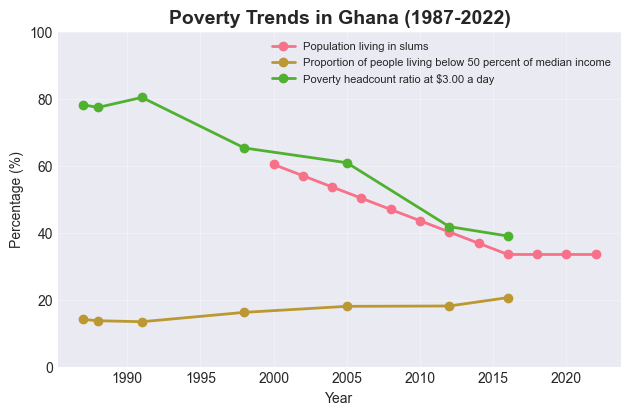

In [6]:
# Prepare data for analysis
def prepare_indicator_data(df, indicator_name):
    """Extract and sort data for a specific indicator"""
    data = df[df['Indicator Name'] == indicator_name].copy()
    data = data.sort_values('Year')
    return data

# Create figure with subplots
fig = plt.figure(figsize=(16, 20))

# 1. POVERTY TRENDS OVER TIME
ax1 = plt.subplot(4, 2, 1)
for indicator in poverty_indicators[:3]:
    data = prepare_indicator_data(df, indicator)
    if len(data) > 0:
        ax1.plot(data['Year'], data['Value'], marker='o', linewidth=2,
                label=indicator.split('(')[0].strip())
ax1.set_title('Poverty Trends in Ghana (1987-2022)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Percentage (%)')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

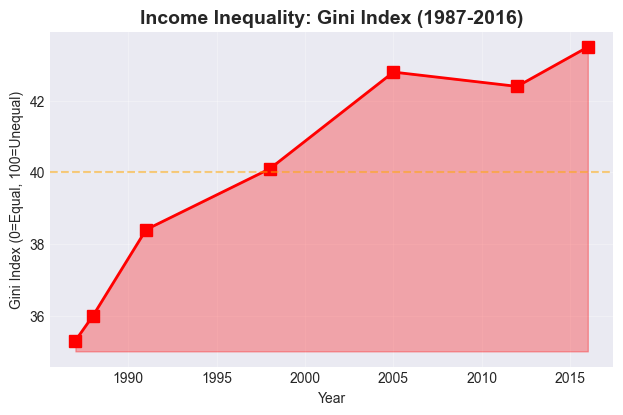

In [16]:
# 2. INEQUALITY TRENDS (GINI INDEX)
fig = plt.figure(figsize=(16, 20))
ax2 = plt.subplot(4, 2, 2)
gini_data = prepare_indicator_data(df, 'Gini index')
if len(gini_data) > 0:
    ax2.plot(gini_data['Year'], gini_data['Value'], marker='s', linewidth=2,
            color='red', markersize=8)
    ax2.fill_between(gini_data['Year'], 35, gini_data['Value'], alpha=0.3, color='red')
ax2.set_title('Income Inequality: Gini Index (1987-2016)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Gini Index (0=Equal, 100=Unequal)')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=40, color='orange', linestyle='--', alpha=0.5, label='Moderate inequality threshold')

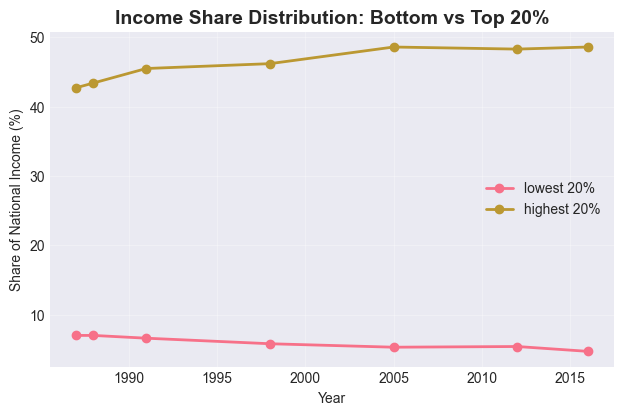

In [15]:
# 3. INCOME SHARE DISTRIBUTION
fig = plt.figure(figsize=(16, 20))
ax3 = plt.subplot(4, 2, 3)
income_shares = ['Income share held by lowest 20%', 'Income share held by highest 20%']
for indicator in income_shares:
    data = prepare_indicator_data(df, indicator)
    if len(data) > 0:
        ax3.plot(data['Year'], data['Value'], marker='o', linewidth=2,
                label=indicator.replace('Income share held by ', ''))
ax3.set_title('Income Share Distribution: Bottom vs Top 20%', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Share of National Income (%)')
ax3.legend()
ax3.grid(True, alpha=0.3)

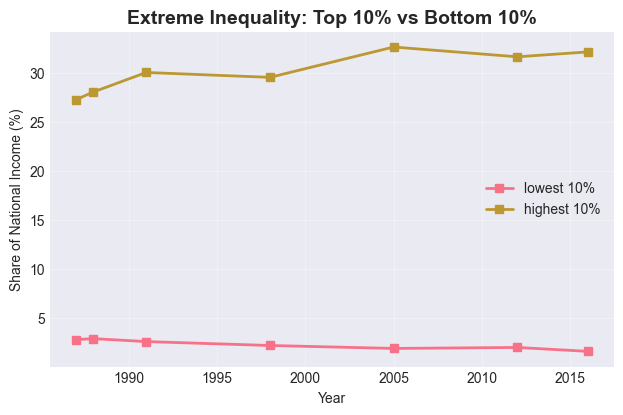

In [14]:
# 4. INCOME SHARE - TOP 10% VS BOTTOM 10%
fig = plt.figure(figsize=(16, 20))
ax4 = plt.subplot(4, 2, 4)
extreme_shares = ['Income share held by lowest 10%', 'Income share held by highest 10%']
for indicator in extreme_shares:
    data = prepare_indicator_data(df, indicator)
    if len(data) > 0:
        ax4.plot(data['Year'], data['Value'], marker='s', linewidth=2,
                label=indicator.replace('Income share held by ', ''))
ax4.set_title('Extreme Inequality: Top 10% vs Bottom 10%', fontsize=14, fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Share of National Income (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)

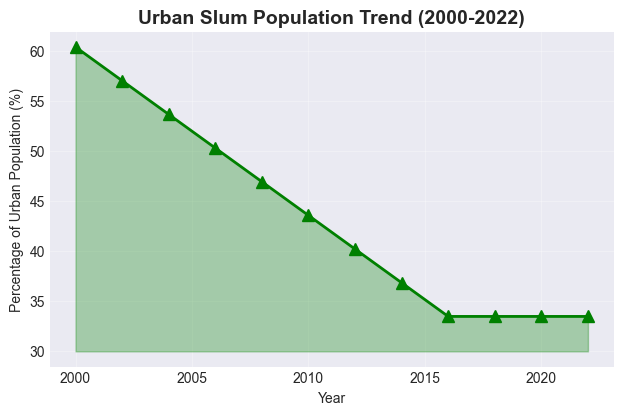

In [13]:
# 5. SLUM POPULATION TREND
fig = plt.figure(figsize=(16, 20))
ax5 = plt.subplot(4, 2, 5)
slum_data = prepare_indicator_data(df, 'Population living in slums (% of urban population)')
if len(slum_data) > 0:
    ax5.plot(slum_data['Year'], slum_data['Value'], marker='^', linewidth=2,
            color='green', markersize=8)
    ax5.fill_between(slum_data['Year'], 30, slum_data['Value'], alpha=0.3, color='green')
ax5.set_title('Urban Slum Population Trend (2000-2022)', fontsize=14, fontweight='bold')
ax5.set_xlabel('Year')
ax5.set_ylabel('Percentage of Urban Population (%)')
ax5.grid(True, alpha=0.3)


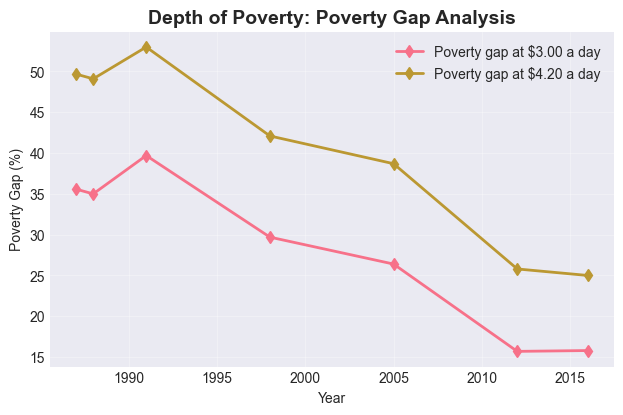

In [12]:
# 6. POVERTY GAP ANALYSIS
fig = plt.figure(figsize=(16, 20))
ax6 = plt.subplot(4, 2, 6)
poverty_gaps = [
    'Poverty gap at $3.00 a day (2021 PPP) (%)',
    'Poverty gap at $4.20 a day (2021 PPP) (%)'
]
for indicator in poverty_gaps:
    data = prepare_indicator_data(df, indicator)
    if len(data) > 0:
        ax6.plot(data['Year'], data['Value'], marker='d', linewidth=2,
                label=indicator.split('(')[0].strip())
ax6.set_title('Depth of Poverty: Poverty Gap Analysis', fontsize=14, fontweight='bold')
ax6.set_xlabel('Year')
ax6.set_ylabel('Poverty Gap (%)')
ax6.legend()
ax6.grid(True, alpha=0.3)

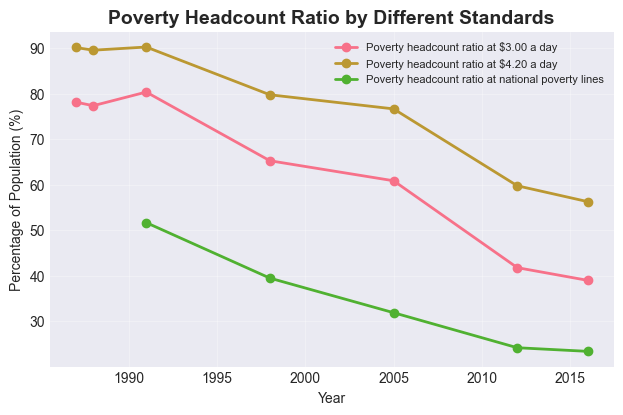

In [17]:
# 7. COMPARATIVE POVERTY LINES
fig = plt.figure(figsize=(16, 20))
ax7 = plt.subplot(4, 2, 7)
poverty_lines = [
    'Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)',
    'Poverty headcount ratio at $4.20 a day (2021 PPP) (% of population)',
    'Poverty headcount ratio at national poverty lines (% of population)'
]
for indicator in poverty_lines:
    data = prepare_indicator_data(df, indicator)
    if len(data) > 0:
        ax7.plot(data['Year'], data['Value'], marker='o', linewidth=2,
                label=indicator.split('(')[0].strip())
ax7.set_title('Poverty Headcount Ratio by Different Standards', fontsize=14, fontweight='bold')
ax7.set_xlabel('Year')
ax7.set_ylabel('Percentage of Population (%)')
ax7.legend(loc='upper right', fontsize=8)
ax7.grid(True, alpha=0.3)

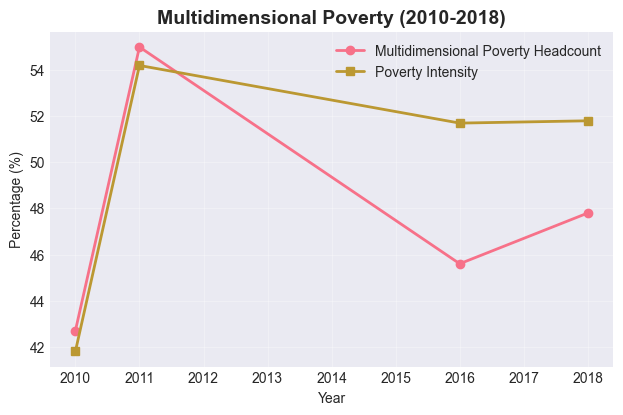

In [20]:
# 8. MULTIDIMENSIONAL POVERTY
fig = plt.figure(figsize=(16, 20))
ax8 = plt.subplot(4, 2, 8)
md_poverty = prepare_indicator_data(df, 'Multidimensional poverty headcount ratio (% of total population)')
md_intensity = prepare_indicator_data(df, 'Multidimensional poverty intensity (average share of deprivations experienced by the poor)')

if len(md_poverty) > 0:
    ax8.plot(md_poverty['Year'], md_poverty['Value'], marker='o', linewidth=2,
            label='Multidimensional Poverty Headcount')
if len(md_intensity) > 0:
    ax8.plot(md_intensity['Year'], md_intensity['Value'], marker='s', linewidth=2,
            label='Poverty Intensity')
ax8.set_title('Multidimensional Poverty (2010-2018)', fontsize=14, fontweight='bold')
ax8.set_xlabel('Year')
ax8.set_ylabel('Percentage (%)')
ax8.legend()
ax8.grid(True, alpha=0.3)

#plt.suptitle('Ghana: Poverty and Inequality Analysis (1987-2022)', fontsize=18, fontweight='bold', y=0.995)
#plt.tight_layout()
#plt.show()

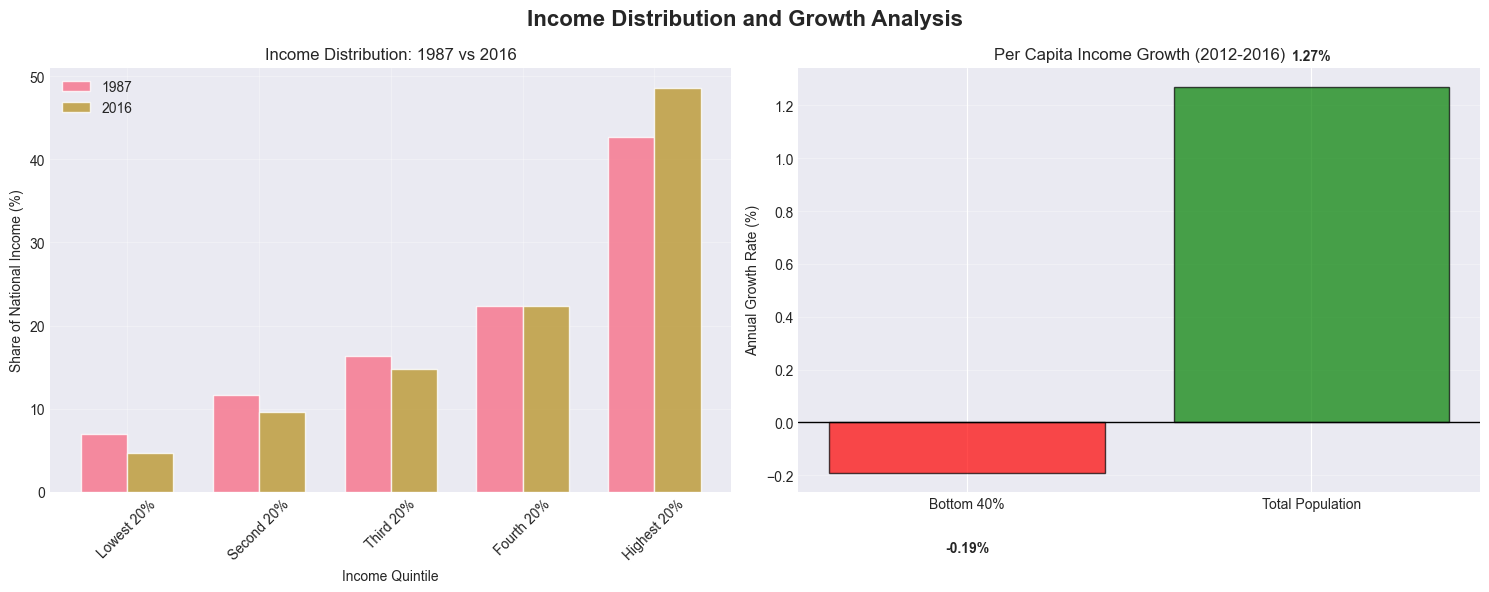

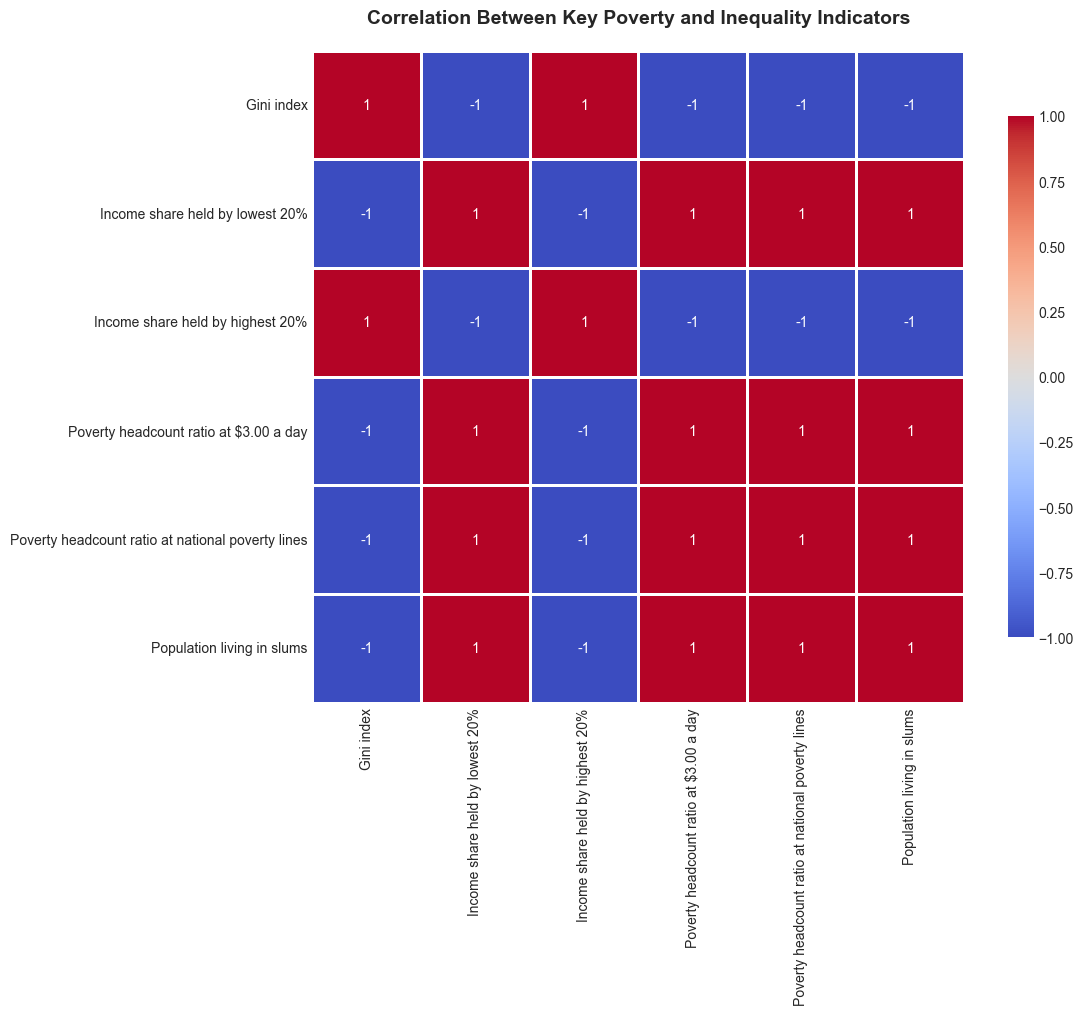

In [23]:
# Create additional visualizations

# Figure 2: Income Quintile Distribution Over Time
fig2, axes = plt.subplots(1, 2, figsize=(15, 6))

# Extract data for all quintiles
quintiles = {
    'Lowest 20%': 'Income share held by lowest 20%',
    'Second 20%': 'Income share held by second 20%',
    'Third 20%': 'Income share held by third 20%',
    'Fourth 20%': 'Income share held by fourth 20%',
    'Highest 20%': 'Income share held by highest 20%'
}

# Find common years for comparison
years_available = set()
for quintile in quintiles.values():
    data = prepare_indicator_data(df, quintile)
    years_available.update(data['Year'].values)
years_available = sorted([y for y in years_available if y in [1987, 2016]])

# Create bar plot comparison
if len(years_available) >= 2:
    year1, year2 = 1987, 2016
    quintile_data = []
    for quintile_name, indicator in quintiles.items():
        data = prepare_indicator_data(df, indicator)
        val1 = data[data['Year'] == year1]['Value'].values[0] if len(data[data['Year'] == year1]) > 0 else None
        val2 = data[data['Year'] == year2]['Value'].values[0] if len(data[data['Year'] == year2]) > 0 else None
        if val1 and val2:
            quintile_data.append([quintile_name, val1, val2])

    if quintile_data:
        quintile_df = pd.DataFrame(quintile_data, columns=['Quintile', str(year1), str(year2)])
        x = np.arange(len(quintile_df))
        width = 0.35

        axes[0].bar(x - width/2, quintile_df[str(year1)], width, label=str(year1), alpha=0.8)
        axes[0].bar(x + width/2, quintile_df[str(year2)], width, label=str(year2), alpha=0.8)
        axes[0].set_xlabel('Income Quintile')
        axes[0].set_ylabel('Share of National Income (%)')
        axes[0].set_title(f'Income Distribution: {year1} vs {year2}')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(quintile_df['Quintile'], rotation=45)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

# Calculate and plot growth rates
bottom40_growth = df[df['Indicator Name'] == 'Annualized average growth rate in per capita real survey mean consumption or income, bottom 40% of population (%)']
total_growth = df[df['Indicator Name'] == 'Annualized average growth rate in per capita real survey mean consumption or income, total population (%)']

if len(bottom40_growth) > 0 and len(total_growth) > 0:
    categories = ['Bottom 40%', 'Total Population']
    growth_rates = [bottom40_growth['Value'].values[0], total_growth['Value'].values[0]]
    colors = ['red' if x < 0 else 'green' for x in growth_rates]

    axes[1].bar(categories, growth_rates, color=colors, alpha=0.7, edgecolor='black')
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[1].set_ylabel('Annual Growth Rate (%)')
    axes[1].set_title('Per Capita Income Growth (2012-2016)')
    axes[1].grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i, v in enumerate(growth_rates):
        axes[1].text(i, v + (0.1 if v >= 0 else -0.3), f'{v:.2f}%', ha='center', fontweight='bold')

plt.suptitle('Income Distribution and Growth Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 3: Correlation Heatmap
fig3, ax = plt.subplots(figsize=(12, 10))

# Create correlation matrix for key indicators
key_indicators = [
    'Gini index',
    'Income share held by lowest 20%',
    'Income share held by highest 20%',
    'Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)',
    'Poverty headcount ratio at national poverty lines (% of population)',
    'Population living in slums (% of urban population)'
]

# Prepare data for correlation
correlation_data = {}
for indicator in key_indicators:
    data = prepare_indicator_data(df, indicator)
    if len(data) > 0:
        # Interpolate to common years
        correlation_data[indicator.split('(')[0].strip()] = data.set_index('Year')['Value']

# Create dataframe for correlation
if correlation_data:
    corr_df = pd.DataFrame(correlation_data)
    corr_df = corr_df.dropna()

    if len(corr_df) > 1:
        corr_matrix = corr_df.corr()

        # Create heatmap
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                   square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
        ax.set_title('Correlation Between Key Poverty and Inequality Indicators',
                    fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [24]:
# Statistical Summary
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)

# Calculate key statistics
print("\n1. POVERTY REDUCTION (1991-2016):")
national_poverty = prepare_indicator_data(df, 'Poverty headcount ratio at national poverty lines (% of population)')
if len(national_poverty) >= 2:
    pct_reduction = ((national_poverty['Value'].iloc[0] - national_poverty['Value'].iloc[-1]) /
                    national_poverty['Value'].iloc[0]) * 100
    print(f"   - National poverty rate reduced from {national_poverty['Value'].iloc[0]:.1f}% to {national_poverty['Value'].iloc[-1]:.1f}%")
    print(f"   - Total reduction: {pct_reduction:.1f}%")

poverty_3usd = prepare_indicator_data(df, 'Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)')
if len(poverty_3usd) >= 2:
    pct_reduction = ((poverty_3usd['Value'].iloc[0] - poverty_3usd['Value'].iloc[-1]) /
                    poverty_3usd['Value'].iloc[0]) * 100
    print(f"   - $3.00/day poverty reduced from {poverty_3usd['Value'].iloc[0]:.1f}% to {poverty_3usd['Value'].iloc[-1]:.1f}%")
    print(f"   - Total reduction: {pct_reduction:.1f}%")

print("\n2. INEQUALITY TRENDS (1987-2016):")
gini = prepare_indicator_data(df, 'Gini index')
if len(gini) >= 2:
    print(f"   - Gini index increased from {gini['Value'].iloc[0]:.1f} to {gini['Value'].iloc[-1]:.1f}")
    print(f"   - Increase of {gini['Value'].iloc[-1] - gini['Value'].iloc[0]:.1f} points")

lowest20 = prepare_indicator_data(df, 'Income share held by lowest 20%')
highest20 = prepare_indicator_data(df, 'Income share held by highest 20%')
if len(lowest20) >= 2 and len(highest20) >= 2:
    print(f"   - Bottom 20% share fell from {lowest20['Value'].iloc[0]:.1f}% to {lowest20['Value'].iloc[-1]:.1f}%")
    print(f"   - Top 20% share rose from {highest20['Value'].iloc[0]:.1f}% to {highest20['Value'].iloc[-1]:.1f}%")
    ratio_1987 = highest20['Value'].iloc[0] / lowest20['Value'].iloc[0]
    ratio_2016 = highest20['Value'].iloc[-1] / lowest20['Value'].iloc[-1]
    print(f"   - Top/Bottom income ratio increased from {ratio_1987:.1f}:1 to {ratio_2016:.1f}:1")

print("\n3. URBAN SLUM POPULATION (2000-2022):")
slum = prepare_indicator_data(df, 'Population living in slums (% of urban population)')
if len(slum) >= 2:
    reduction = ((slum['Value'].iloc[0] - slum['Value'].iloc[-1]) / slum['Value'].iloc[0]) * 100
    print(f"   - Slum population reduced from {slum['Value'].iloc[0]:.1f}% to {slum['Value'].iloc[-1]:.1f}%")
    print(f"   - Reduction of {reduction:.1f}%")

print("\n4. RECENT TRENDS (2012-2016):")
bottom40_mean = df[df['Indicator Name'] == 'Survey mean consumption or income per capita, bottom 40% of population (2021 PPP $ per day)']
total_mean = df[df['Indicator Name'] == 'Survey mean consumption or income per capita, total population (2021 PPP $ per day)']
if len(bottom40_mean) >= 2 and len(total_mean) >= 2:
    print(f"   - Bottom 40% mean income: ${bottom40_mean['Value'].iloc[0]:.2f} → ${bottom40_mean['Value'].iloc[-1]:.2f} per day")
    print(f"   - Total population mean income: ${total_mean['Value'].iloc[0]:.2f} → ${total_mean['Value'].iloc[-1]:.2f} per day")

print("\n" + "=" * 80)
print("KEY FINDINGS:")
print("=" * 80)
print("✓ Significant poverty reduction (51.7% → 23.4% at national line)")
print("✓ Substantial improvement in urban living conditions (60.4% → 33.5% slum population)")
print("✗ Rising inequality (Gini index: 35.3 → 43.5)")
print("✗ Bottom 20% income share decreased while top 20% increased")
print("⚠ Growth has been pro-rich (bottom 40% experienced negative growth 2012-2016)")
print("=" * 80)


STATISTICAL SUMMARY

1. POVERTY REDUCTION (1991-2016):
   - National poverty rate reduced from 51.7% to 23.4%
   - Total reduction: 54.7%
   - $3.00/day poverty reduced from 78.2% to 39.0%
   - Total reduction: 50.1%

2. INEQUALITY TRENDS (1987-2016):
   - Gini index increased from 35.3 to 43.5
   - Increase of 8.2 points
   - Bottom 20% share fell from 7.0% to 4.7%
   - Top 20% share rose from 42.7% to 48.6%
   - Top/Bottom income ratio increased from 6.1:1 to 10.3:1

3. URBAN SLUM POPULATION (2000-2022):
   - Slum population reduced from 60.4% to 33.5%
   - Reduction of 44.5%

4. RECENT TRENDS (2012-2016):
   - Bottom 40% mean income: $1.81 → $1.83 per day
   - Total population mean income: $5.07 → $4.82 per day

KEY FINDINGS:
✓ Significant poverty reduction (51.7% → 23.4% at national line)
✓ Substantial improvement in urban living conditions (60.4% → 33.5% slum population)
✗ Rising inequality (Gini index: 35.3 → 43.5)
✗ Bottom 20% income share decreased while top 20% increased
⚠ Gr